In [2]:
# Import necessary libraries and configure matplotlib parameters
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import math
import time
import tqdm
import gc
import matplotlib as mpl
from scipy import stats
from numba import njit, prange
import seaborn as sns
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import NullLocator
from matplotlib.ticker import AutoMinorLocator
from matplotlib.ticker import MultipleLocator
from brokenaxes import brokenaxes

mpl.rcdefaults()
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 18
plt.rcParams['lines.linewidth'] = 2.8
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['axes.xmargin'] = 0.05
plt.rcParams['axes.grid']='True'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = 'True'
plt.rcParams['ytick.right'] = 'True'
plt.rcParams['xtick.minor.visible'] ='True'
plt.rcParams['ytick.minor.visible'] ='True'
plt.rcParams['xtick.major.size'] =10
plt.rcParams['xtick.minor.size'] =5
plt.rcParams['xtick.major.width'] =2
plt.rcParams['xtick.minor.width'] =1
plt.rcParams['xtick.major.pad']=8
plt.rcParams['ytick.major.size'] =10
plt.rcParams['ytick.minor.size'] =5
plt.rcParams['ytick.major.width'] =2
plt.rcParams['ytick.minor.width'] =1
plt.rcParams['ytick.major.pad']=8
plt.rcParams['figure.subplot.wspace']=0.25
plt.rcParams['figure.subplot.hspace']=0.5
plt.rcParams['grid.color'] = 'lightgray'
plt.rcParams['grid.linewidth'] = 2
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.8
plt.rcParams['savefig.bbox']='tight'
plt.rcParams['savefig.format']='pdf'
rc_dict = mpl.rcParams.copy()

In [4]:
# Read burst table
def Xreaddata(path, col_indices, new_col_names, startrow=0):
    if len(col_indices) != len(new_col_names):
        raise ValueError("The number of column indices must match the number of new column names.")
    df_0 = pd.read_csv(path, dtype=str)
    df = df_0.iloc[startrow:, col_indices]
    df.columns = new_col_names
    for col in df.columns:
        try:
            df[col] = df[col].astype(float)
        except ValueError:
            pass
    df = df.fillna(np.nan)
    df = df.sort_values(by='t')
    df = df.reset_index(drop=True)
    return df_0, df
    
b_fast1=Xreaddata('Data/20201124A/Burst_Table/FAST#1.csv',
            [0,2,6,4],['t','s','w','f'],
            startrow=0)

b_fast2=Xreaddata('Data/20201124A/Burst_Table/FAST#2.csv',
            [2,5,4,7],['t','s','w','f'],
            startrow=2) 
b_fast2[1]['s']=b_fast2[1]['s']/1000

b_ugmrt=Xreaddata('Data/20201124A/Burst_Table/uGMRT.csv',
            [1,4,2,5],['t','s','w','f'],
            startrow=0)  

b_effelsberg=Xreaddata('Data/20201124A/Burst_Table/Effelsberg.csv',
            [1,5,3,7],['t','s','w','f'],
            startrow=0)  

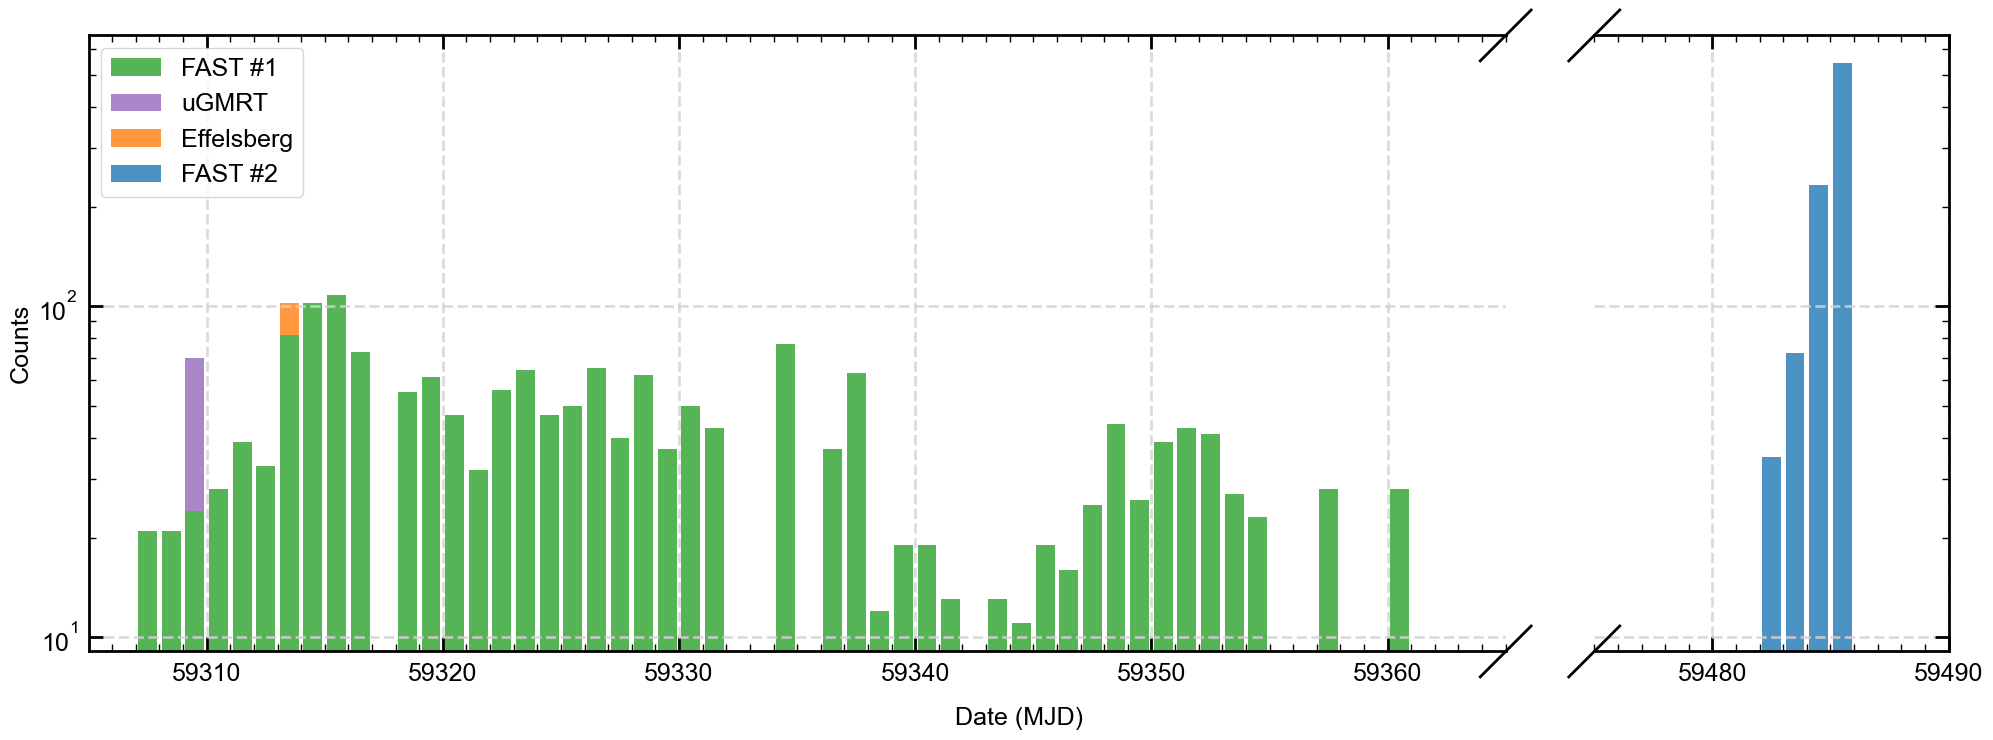

In [9]:
# Plot Figure 1
fig = plt.figure(figsize=(24,8))
bax = brokenaxes(xlims=((59305, 59365), (59475, 59490)), 
                 # ylims=(0,600),
                 wspace=0.1,despine=False,diag_color='k')
bax.hist(
    [b_fast1[1]['t'], b_ugmrt[1]['t'], b_effelsberg[1]['t']],
    bins = np.arange(np.floor(b_fast1[1]['t'].min()) - 1, np.ceil(b_fast1[1]['t'].max()) + 2, 1),
    # stacked=True, 
    label=[
        'FAST #1', 
        'uGMRT', 
        'Effelsberg', 
    ],
    color=['#2ca02c', '#9467bd', '#ff7f0e'],
    histtype='barstacked',
    rwidth=0.8,
    alpha=0.8
)
bax.hist(b_fast2[1]['t'],
         bins=np.arange(np.floor(b_fast2[1]['t'].min()) - 1, np.ceil(b_fast2[1]['t'].max()) + 2, 1),
         label='FAST #2',color='#1f77b4',rwidth=0.8, alpha=0.8 )
bax.set_xlabel('Date (MJD)', labelpad=40)
bax.set_ylabel('Counts', labelpad=40)
bax.set_yscale('log')
bax.legend(loc='upper left')
bax.axs[1].xaxis.set_ticks_position('both')
bax.axs[1].yaxis.set_ticks_position('right')
bax.axs[1].yaxis.set_tick_params(labelright=False)
bax.axs[0].xaxis.set_ticks_position('both')
bax.axs[0].yaxis.set_ticks_position('left')
for ax in bax.axs:
    ax.grid(True)  
for ax in bax.axs:
    ax.xaxis.set_minor_locator(MultipleLocator(1))


In [6]:
#Further reduce the data table
def Xselectdata2(df_s, nummin, dnum, sep):
    t_bins = np.arange(np.floor(df_s['t'].min()) - (1 - sep), np.ceil(df_s['t'].max()) + (1 - sep) + dnum, dnum)
    num, _ = np.histogram(df_s['t'], t_bins)
    date_s = np.where(num >= nummin)[0]
    date_s = date_s * dnum
    df_list = []
    for date in date_s:
        mask = np.logical_and(df_s['t'] > (date + np.floor(df_s['t'].min()) - (1 - sep)), 
                              df_s['t'] < (date + np.floor(df_s['t'].min()) - (1 - sep)) + dnum)
        df_temp = df_s.loc[mask, :].reset_index(drop=True)
        df_temp.columns = [f'{col}' for col in df_temp.columns] 
        df_list.append(df_temp)
    return df_s, df_list
    
def burstverify_anyday(bi,nummin,dnum,sep) :
    bi_ss=Xselectdata2(bi[1],nummin=nummin,dnum=dnum,sep=sep)
    b_s=[]
    for i in range(len(bi_ss[1])):
        b_s.append(bi_ss[1][i]['t']*86400)
        bi_ss[1][i]['t_s']=b_s[i]   
        waitingtime=np.diff(b_s[i])
        bi_ss[1][i]['waitingtime']=np.concatenate(([np.inf],waitingtime))
    return bi_ss
    
def get_cluster_representatives(df_day, threshold):
    df = df_day.sort_values('t_s').reset_index(drop=True).copy()
    t = df['t_s'].to_numpy(np.float64)
    dt_prev = np.empty_like(t)
    dt_prev[0] = np.inf
    dt_prev[1:] = np.diff(t)
    n = len(df)
    cluster_id = np.empty(n, dtype=np.int32)
    cid = 0
    for i in range(n):
        if i == 0:
            cluster_id[i] = cid
        else:
            if dt_prev[i] < threshold:
                cluster_id[i] = cid
            else:
                cid += 1
                cluster_id[i] = cid
    df['cluster_id'] = cluster_id
    reps = []
    for _, g in df.groupby('cluster_id', sort=False):
        idx = g['s'].idxmax()
        rep = g.loc[idx].copy()
        reps.append(rep)
    return pd.DataFrame(reps).reset_index(drop=True)
        
# Reduce FAST#1 data
b_ss=burstverify_anyday(b_fast1, nummin=1,dnum=1,sep=0)


 50%|██████████████████████████████████████████                                          | 1/2 [00:01<00:01,  1.59s/it]


MJD 59310
Period: 1.70603 s
Chi2: 6.05


100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.10s/it]


MJD 59347
Period: 1.70797 s
Chi2: 5.28


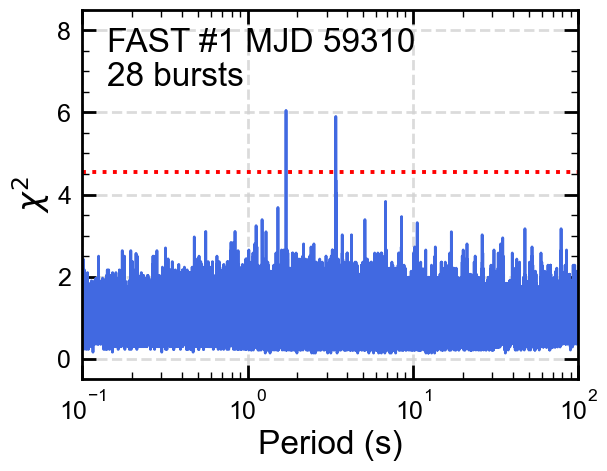

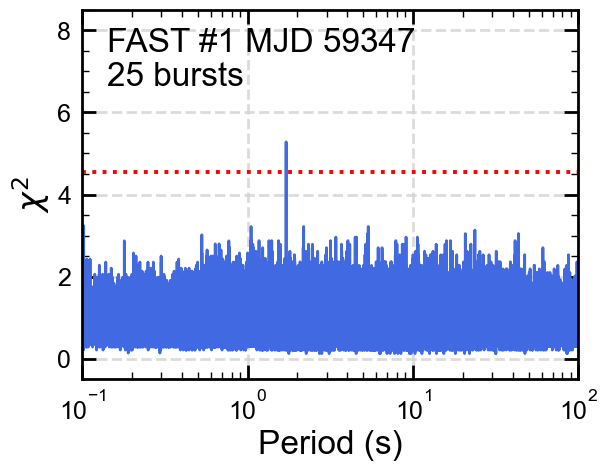

In [8]:
# Phase folding algorithm for periodicity analysis (numba)
@njit(parallel=True, fastmath=True)
def phase_fold_and_calc_chi2_opt(t, p_arr, bins_num):
    N = t.shape[0]
    M = p_arr.shape[0]
    chi_arr = np.empty(M, dtype=np.float32)
    q = 1.0 + (bins_num + 1) / (6.0 * N)      # Williams correction
    E = N / bins_num                          
    inv_norm = 1.0 / (E * (bins_num - 1) * q) 
    for i in prange(M):
        p = p_arr[i]
        inv_p = 1.0 / p
        O = np.zeros(bins_num, dtype=np.int32)
        for n in range(N):
            phase = (t[n] * inv_p) % 1.0   # in [0, 1)
            idx = int(phase * bins_num)
            if idx == bins_num:
                idx = bins_num - 1
            O[idx] += 1
        s2 = 0.0
        for b in range(bins_num):
            cnt = float(O[b])
            s2 += cnt * cnt
        chi_arr[i] = (s2 - N * E) * inv_norm
    return chi_arr


def segmented_search_chi2(b_ss, day, ps, pe, step, bins_num, threshold):
    def _get_rep_times(df_day, threshold):
        b_rep = get_cluster_representatives(df_day, threshold)
        return np.asarray(b_rep["t_s"], dtype=np.float64)
    if step <= 0:
        raise ValueError("Step size must be positive.")
    if pe < ps:
        raise ValueError("End period must be greater than start period.")
    df_day = b_ss[1][day]
    num_points = int(np.round((pe - ps) / step)) + 1
    p_arr = np.linspace(ps, pe, num_points, dtype=np.float64)
    
    split = float(threshold) * 2.0
    t_all = np.asarray(df_day["t_s"], dtype=np.float64)
    mask_long = p_arr >= split
    has_long = np.any(mask_long)
    has_short = np.any(~mask_long)
    if not has_long:
        chi2_arr = phase_fold_and_calc_chi2_opt(t_all, p_arr, bins_num)
    
    elif not has_short:
        t_rep = _get_rep_times(df_day, threshold)
        chi2_arr = phase_fold_and_calc_chi2_opt(t_rep, p_arr, bins_num)
    
    else:
        p_short = p_arr[~mask_long]
        p_long  = p_arr[mask_long]
        
        chi2_short = phase_fold_and_calc_chi2_opt(t_all, p_short, bins_num)
        
        t_rep = _get_rep_times(df_day, threshold)
        chi2_long = phase_fold_and_calc_chi2_opt(t_rep, p_long, bins_num)
        
        chi2_arr = np.concatenate([chi2_short, chi2_long])
        
        del chi2_short, chi2_long
        gc.collect()
    best_idx = np.argmax(chi2_arr)
    best_p = p_arr[best_idx]
    result = {
        "chi2_array": chi2_arr.astype(np.float32),
        "best_p": best_p,  
        "max_chi2": chi2_arr[best_idx],
        "MJD": np.floor(np.min(df_day["t"])) if len(df_day) > 0 else 0,
        "N_burst": int(len(df_day)),
    }
    return result


b_ss=burstverify_anyday(b_fast1, nummin=1,dnum=1,sep=0)
gc.collect()
# Periodograms of MJDs 59310 and 59347
for i in tqdm.tqdm([3,35]):
    ps=0.1
    pe=100
    step=1e-5
    threshold = 0.5
    bins_num = 20
    xxx=stats.chi2.isf((1 - stats.norm.cdf(3))/((pe-ps)/step), bins_num-1)/(bins_num-1)
    r=segmented_search_chi2(b_ss, i, ps, pe, step, bins_num, threshold)
    fig, ax=plt.subplots()
    ax.plot(np.linspace(ps,pe,int(np.round((pe-ps)/step))+1), r['chi2_array'], alpha=1, lw=2, color='royalblue')
    ax.set_xscale('log')
    ax.axhline(xxx, color='red', linestyle='dotted')
    ax.text(0.05, 0.95, 'FAST #1 MJD %i' % r['MJD'], transform=ax.transAxes, fontsize=24,
              verticalalignment='top', horizontalalignment='left')
    ax.text(0.05, 0.86, '%i bursts' % r['N_burst'], transform=ax.transAxes, fontsize=24,
              verticalalignment='top', horizontalalignment='left')
    ax.set_xlim(ps, pe)
    ax.yaxis.set_major_locator(MultipleLocator(2))
    ax.set_ylim(-0.5,8.5)
    ax.set_xlabel('Period (s)',fontsize=24)
    ax.set_ylabel('$\\chi^2$',fontsize=24)
    print(f"\nMJD {int(r['MJD'])}")
    print(f"Period: {r['best_p']:.5f} s")
    print(f"Chi2: {r['max_chi2']:.2f}")
    # plt.close(fig)   
    # plt.close('all') 
    # del r, fig, ax
    gc.collect()

(0.0, 2.0)

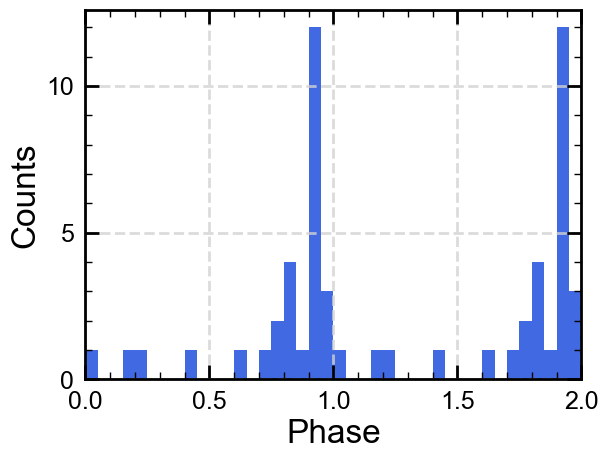

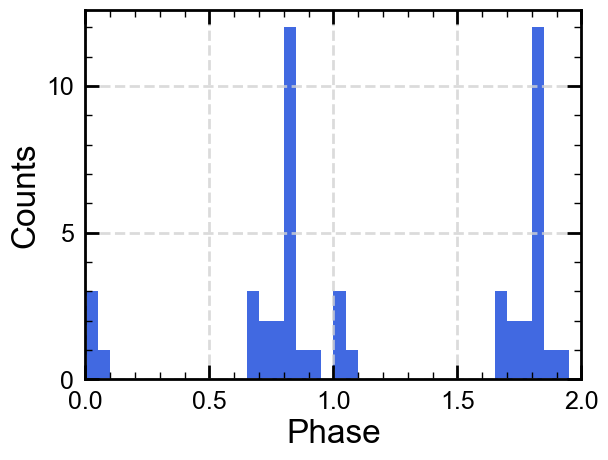

In [10]:
# Draw phase histograms according to refined period
# For details on how refined periods were obtained, please refer to "Plotting Extended Data Figures.ipynb".
def get_phase(t, period):
    phase = np.fmod(t/period, 1.0)
    phase = np.where(phase < 0.0, phase + 1.0, phase)
    return phase

b_ss_fast1=burstverify_anyday(b_fast1,nummin=1,dnum=1,sep=0)

folded_phases_59310 = get_phase(b_ss_fast1[1][3]['t_s']-np.mean(b_ss_fast1[1][3]['t_s']),1.706024)
fig,ax=plt.subplots(1,1)
plt.hist(folded_phases_59310, np.linspace(0,1,21), weights=None,color='royalblue',alpha=1)
plt.hist(folded_phases_59310+1, np.linspace(1,2,21), weights=None,color='royalblue',alpha=1)
plt.ylabel('Counts',fontsize=24)
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(1))
plt.xlabel('Phase',fontsize=24)
ax.set_xlim(0,2)

folded_phases_59347 = get_phase(b_ss_fast1[1][35]['t_s']-np.mean(b_ss_fast1[1][35]['t_s']),1.707968)
fig,ax=plt.subplots(1,1)
plt.hist(folded_phases_59347, np.linspace(0,1,21), weights=None,color='royalblue',alpha=1)
plt.hist(folded_phases_59347+1, np.linspace(1,2,21), weights=None,color='royalblue',alpha=1)
plt.ylabel('Counts',fontsize=24)
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(1))
plt.xlabel('Phase',fontsize=24)
ax.set_xlim(0,2)

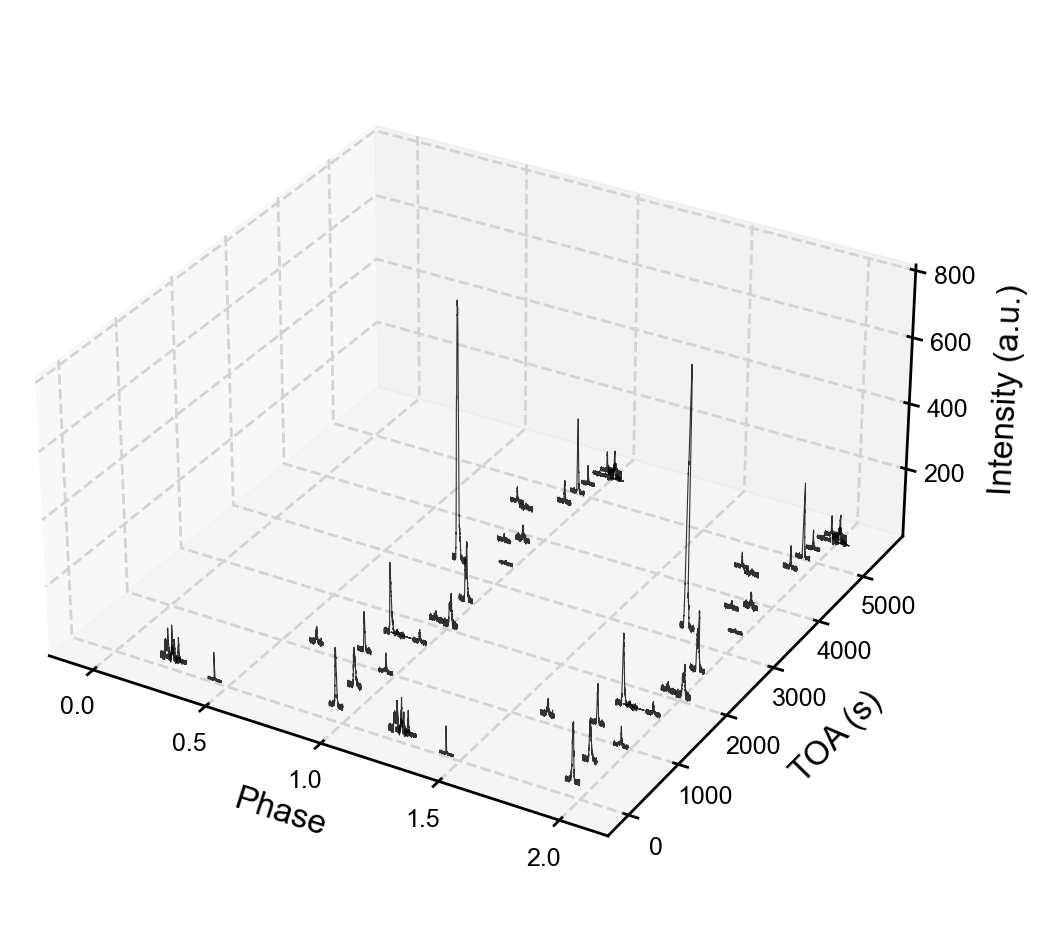

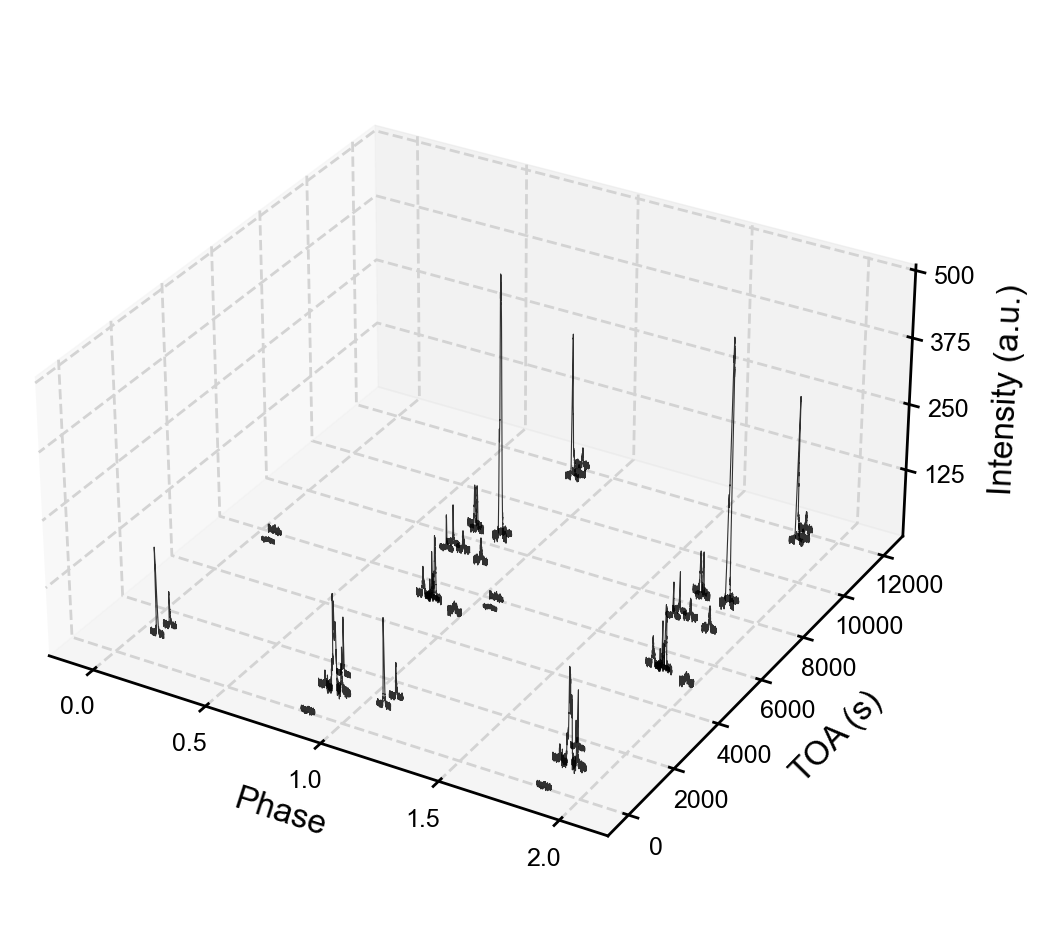

In [17]:
# Plot Figure 3
DATA_np = np.load('Data/20201124A/FAST#1_1863_Bursts/DATA_list.npy', allow_pickle=True)
SNR_np = np.load('Data/20201124A/FAST#1_1863_Bursts/SNR_list.npy', allow_pickle=True)
MJD_np = np.load('Data/20201124A/FAST#1_1863_Bursts/MJD_list.npy', allow_pickle=True)
Nbin_np = np.load('Data/20201124A/FAST#1_1863_Bursts/Nbin_list.npy', allow_pickle=True)

def Xselectdatas(mjd_np, x_np, nummin, dnum, sep):
    t_bins = np.arange(np.floor(MJD_np.min()) - (1 - sep), np.ceil(MJD_np.max()) + (1 - sep) + dnum, dnum)
    num, _ = np.histogram(MJD_np, t_bins)
    date_s = np.where((num >= nummin))[0]
    date_s = date_s * dnum
    df_list = []
    for date in date_s:
        mask = np.logical_and(MJD_np > (date + np.floor(MJD_np.min()) - (1 - sep)), 
                              MJD_np < (date + np.floor(MJD_np.min()) - (1 - sep)) + dnum)
        df_temp = x_np[mask]
        df_list.append(df_temp)
    return  df_list

DATA_ss=Xselectdatas(MJD_np, DATA_np, nummin=10, dnum=1, sep=0)
SNR_ss=Xselectdatas(MJD_np, SNR_np, nummin=10, dnum=1, sep=0)
NBIN_ss=Xselectdatas(MJD_np, Nbin_np, nummin=10, dnum=1, sep=0)
MJD_ss=Xselectdatas(MJD_np, MJD_np, nummin=10, dnum=1, sep=0)

day=3 # MJD 59310

fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111, projection='3d')
t_59310 = np.mean(b_ss[1][day]['t_s']) # MJD 59310 mean TOA
p_59310 = 1.706024
for i in range(len(MJD_ss[day])):
    t=(MJD_ss[day][i]) * 86400-t_59310
    Y_i = (MJD_ss[day][i]-MJD_ss[day][0]) * 86400
    Z_i = (DATA_ss[day][i]/max(DATA_ss[day][i]))*SNR_ss[day][i]
    P_i= get_phase(t,p_59310)
    X_i = np.linspace(P_i, P_i + (NBIN_ss[day][i]) * (0.000196608 / (p_59310)), NBIN_ss[day][i].astype(np.int64))
    ax.plot(X_i, np.full_like(X_i, Y_i), Z_i, color='k', linewidth=0.8,alpha=0.8)
    ax.plot(X_i+1, np.full_like(X_i, Y_i), Z_i, color='k', linewidth=0.8,alpha=0.8)
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='z', direction='in')
ax.set_xlim(-0.15, 2.15)
ax.set_zticks([200,400,600,800])
ax.set_zlim(7, 800)
ax.set_xlabel('Phase',fontsize=24, labelpad=20)
ax.set_ylabel('TOA (s)',fontsize=24, labelpad=25)
ax.set_zlabel('Intensity (a.u.)',fontsize=24, labelpad=20)
ax.text2D(1.1, 0.5, '            ', transform=ax.transAxes,
         va='center',
         ha='center', 
         rotation='vertical')
ax.set_box_aspect([2, 2, 1]) 
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())
ax.zaxis.set_minor_locator(NullLocator())


day=35 # MJD 59347

fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111, projection='3d')
t_59347 = np.mean(b_ss[1][day]['t_s']) # MJD 59347 mean TOA
p_59347 = 1.707968
for i in range(len(MJD_ss[day])):
    t=(MJD_ss[day][i]) * 86400-t_59347
    Y_i = (MJD_ss[day][i]-MJD_ss[day][0]) * 86400
    Z_i = (DATA_ss[day][i]/max(DATA_ss[day][i]))*SNR_ss[day][i]
    P_i= get_phase(t,p_59347)
    X_i = np.linspace(P_i, P_i + (NBIN_ss[day][i]) * (0.000196608 / (p_59347)), NBIN_ss[day][i].astype(np.int64))
    ax.plot(X_i, np.full_like(X_i, Y_i), Z_i, color='k', linewidth=0.8,alpha=0.8)
    ax.plot(X_i+1, np.full_like(X_i, Y_i), Z_i, color='k', linewidth=0.8,alpha=0.8)
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='z', direction='in')
ax.set_xlim(-0.15, 2.15)
ax.set_zticks([125,250,375,500])
ax.set_zlim(7, 500)
ax.set_xlabel('Phase',fontsize=24, labelpad=20)
ax.set_ylabel('TOA (s)',fontsize=24, labelpad=25)
ax.set_zlabel('Intensity (a.u.)',fontsize=24, labelpad=20)
ax.text2D(1.1, 0.5, '            ', transform=ax.transAxes,
         va='center', 
         ha='center', 
         rotation='vertical')
ax.set_box_aspect([2, 2, 1]) 
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())
ax.zaxis.set_minor_locator(NullLocator())



Text(0, 0.5, '$\\dot P$ (s s$^{-1}$)')

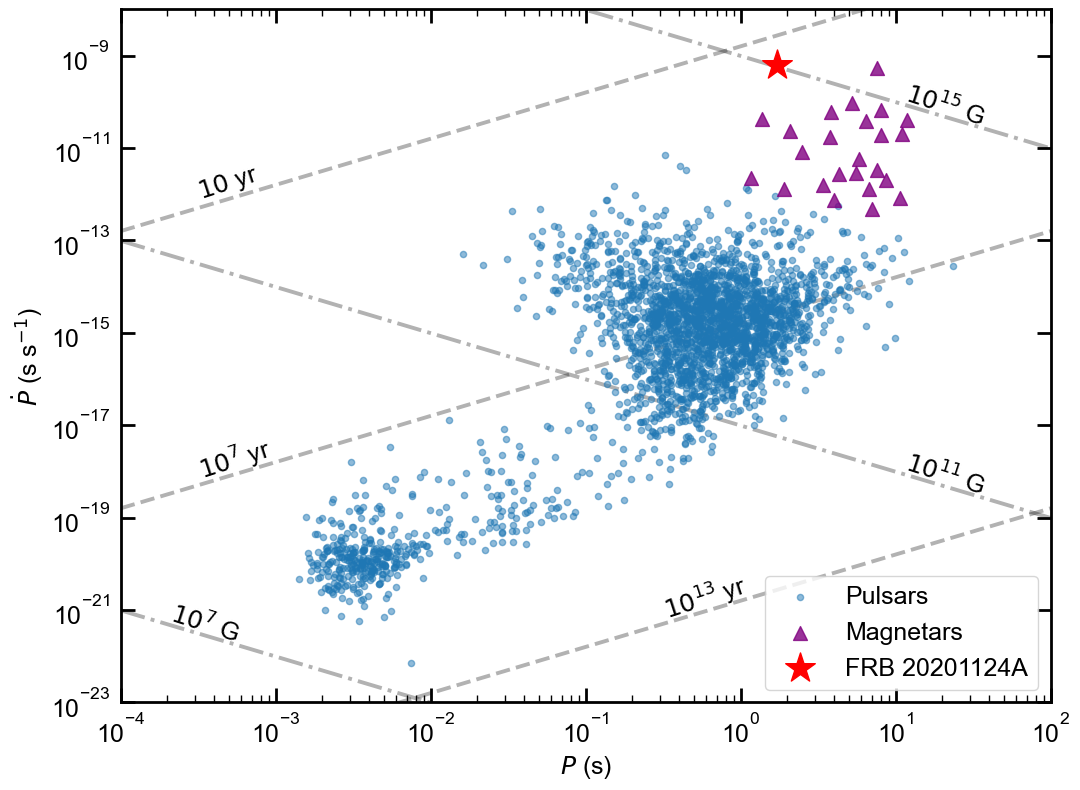

In [19]:
# Plot Figure 4
def Xreadpulsar(path, col_indices, new_col_names, startrow=0):
    if len(col_indices) != len(new_col_names):
        raise ValueError("The number of column indices must match the number of new column names.")
    df_0 = pd.read_csv(path)
    df = df_0.iloc[startrow:, col_indices]
    df.columns = new_col_names
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.fillna(np.nan)
    df = df.reset_index(drop=True)
    return df_0, df

pulsars = Xreadpulsar('Data/pulsar.csv',
                      [1, 3, 6], ['name', 'p0', 'p1'],
                      startrow=3)
fig, ax=plt.subplots(1,1,figsize=(12,9))
plt.scatter(pulsars[1]['p0'].loc[3.2e19*(pulsars[1]['p0']*pulsars[1]['p1'])**0.5<0.5e14],
            pulsars[1]['p1'].loc[3.2e19*(pulsars[1]['p0']*pulsars[1]['p1'])**0.5<0.5e14],
            marker='o',s=20,alpha=0.5,label='Pulsars')
plt.scatter(pulsars[1]['p0'].loc[3.2e19*(pulsars[1]['p0']*pulsars[1]['p1'])**0.5>=0.5e14],
            pulsars[1]['p1'].loc[3.2e19*(pulsars[1]['p0']*pulsars[1]['p1'])**0.5>=0.5e14],
            color='purple',marker='^',s=100,alpha=0.8,label='Magnetars')
plt.scatter(1.707,6.11e-10,marker='*',s=500,color='red',label='FRB 20201124A')
plt.xscale('log')
plt.yscale('log')
plt.text(11,0.3e-10,'$10^{15}$ G',rotation=-18)
plt.text(11,3e-19,'$10^{11}$ G',rotation=-18)
plt.text(2E-4,0.2e-21,'$10^{7}$ G',rotation=-18)
plt.text(3e-4,0.08e-11,'$10$ yr',rotation=18)
plt.text(3e-4,0.07e-17,'$10^7$ yr',rotation=18)
plt.text(0.3,0.65e-21,'$10^{13}$ yr',rotation=18)
plt.legend(loc='lower right')
plt.xlim(1e-4,100)
plt.ylim(1e-23,1e-8)
xlim=ax.get_xlim()
ylim=ax.get_ylim()
plt.grid()
p0=np.linspace(xlim[0],xlim[1],100)
for logb in (7,11,15) :
    plt.plot((p0),((10**(logb)/3.2e19)**2)/p0,'-.',alpha=0.3,c='k',zorder=-1)
for logt in (1,7,13) :
    plt.plot((p0),p0/(2*(10**(logt)*86400*365)),'--',alpha=0.3,c='k',zorder=-1)
ax.autoscale(enable=False)
plt.xlabel('$P$ (s)')
plt.ylabel('$\\dot P$ (s s$^{-1}$)')

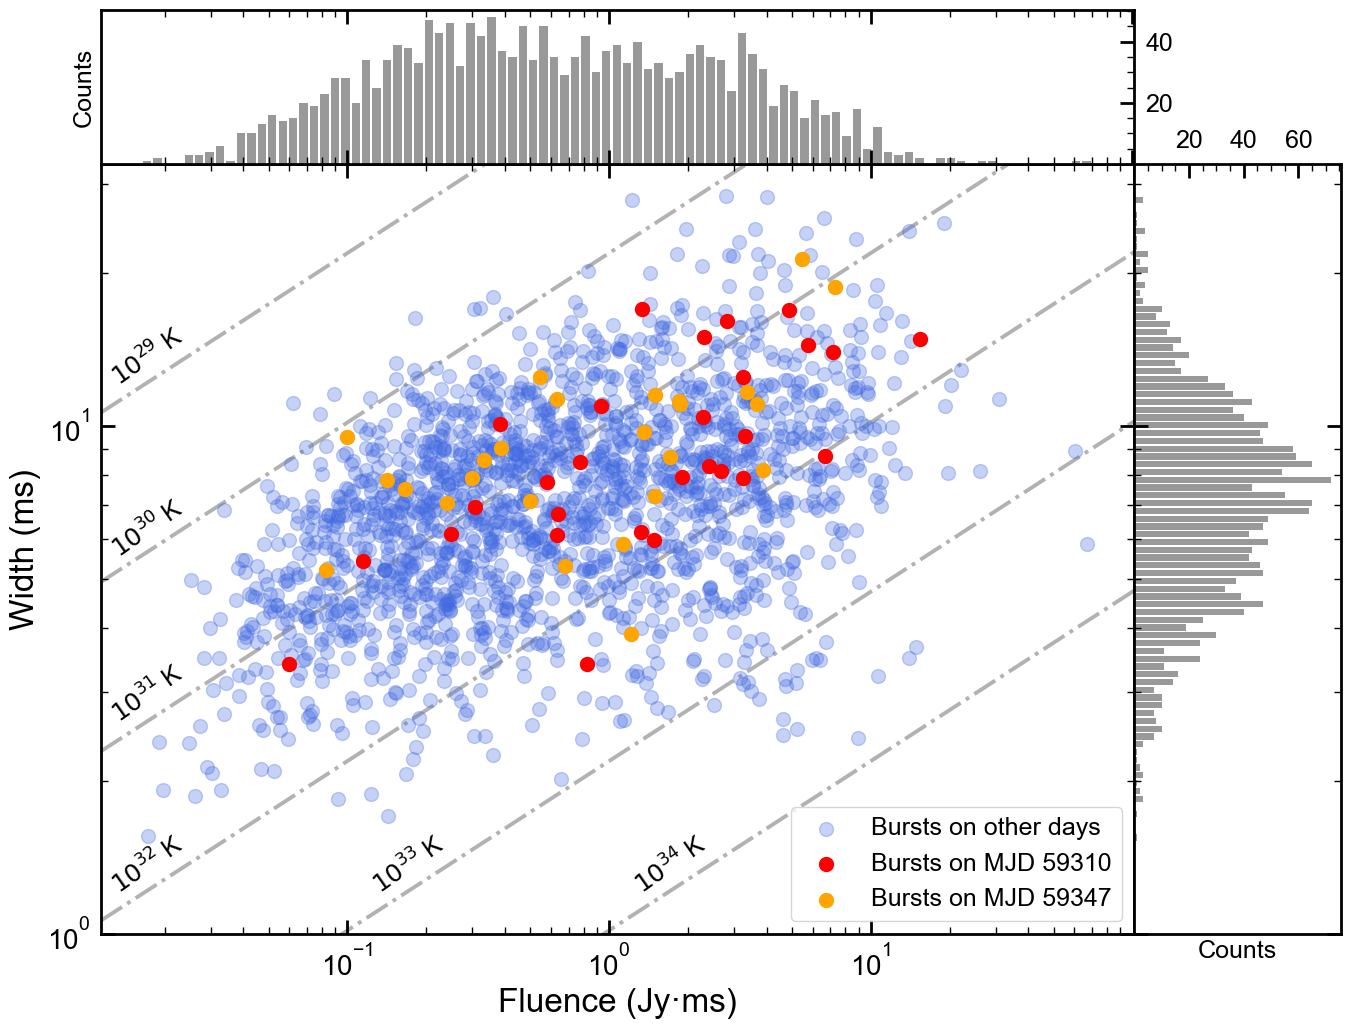

In [12]:
# Plot Figure 5
b_ss=burstverify_anyday(b_fast1, nummin=1,dnum=1,sep=0)
fig = plt.figure(figsize=(16, 12))
ax = plt.subplot() 
ax.scatter(b_fast1[1]['f'], b_fast1[1]['w'], marker='o',c='royalblue', label='Bursts on other days', alpha=0.3, s=100)
ax.scatter(b_ss[1][3]['f'], b_ss[1][3]['w'], marker='o',c='red', label='Bursts on MJD 59310',alpha=1, s=100)
ax.scatter(b_ss[1][35]['f'], b_ss[1][35]['w'], marker='o',c='orange', label='Bursts on MJD 59347',alpha=1, s=100)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=18,loc='lower right')
ax.tick_params(axis='both', labelsize=20)
ax.set_xticks([0.1,1,10])
ax.set_yticks([1,10])
ax.set_xlabel('Fluence (Jy·ms)',fontsize=24)
ax.set_ylabel('Width (ms)',fontsize=24)
plt.grid()
xlim=ax.get_xlim()
ylim=ax.get_ylim()
ax_joint = ax
x=np.linspace(xlim[0],xlim[1],100)
m=np.arange(29,35,1.0)
for i in m :
    ax.plot((x),(x*1.25**(-2)*0.3861**2*1.1*10**(35-i))**(1/3),'-.',alpha=0.3,c='k',zorder=-1)
    ax.autoscale(enable=False)
ax.autoscale(enable=False)
ax.text(0.12, 1.2, '$10^{33}$ K'
        , fontsize=18, rotation=35)
ax.text(1.2,1.2, '$10^{34}$ K'
        , fontsize=18, rotation=35)
ax.text(0.012, 1.2, '$10^{32}$ K'
        , fontsize=18, rotation=35)
ax.text(0.012, 2.6, '$10^{31}$ K'
        , fontsize=18, rotation=35)
ax.text(0.012, 5.5, '$10^{30}$ K'
        , fontsize=18, rotation=35)
ax.text(0.012, 12, '$10^{29}$ K'
        , fontsize=18, rotation=35)

divider = make_axes_locatable(ax)
ax_f = divider.append_axes('top', size='20%', pad=0)
plt.grid()
ax_w = divider.append_axes('right', size='20%', pad=0)
plt.grid()

f_counts, f_bins = np.histogram(b_fast1[1]['f'], bins=np.logspace(np.log10(xlim[0]), np.log10(xlim[1]), 100))
ax_f.bar(f_bins[:-1], f_counts, width=np.diff(f_bins)*0.8, align='edge', color='grey', alpha=0.8,label='FRB 20201124A_FAST')
ax_f.set_xscale('log')
ax_f.set_xlim(xlim)
ax_f.set_xticklabels([])
ax_f.set_yticks([20,40])
ax_f.set_ylabel('Counts', fontsize=18)
ax_f.yaxis.set_ticks_position('right')
ax_f.yaxis.set_label_position('left')
ax_f.tick_params(axis='both', which='both', direction='in', labelsize=18)

w_counts, w_bins = np.histogram(b_fast1[1]['w'], bins=np.logspace(np.log10(ylim[0]), np.log10(ylim[1]), 100))
ax_w.barh(w_bins[:-1], w_counts, height=np.diff(w_bins)*0.8, align='edge', color='grey', alpha=0.8,label='FRB 20201124A_FAST')
ax_w.set_yscale('log')
ax_w.set_ylim(ylim)
ax_w.set_yticklabels([])
ax_w.set_xticks([20,40,60])
ax_w.set_xlabel('Counts', fontsize=18)
ax_w.xaxis.set_ticks_position('top')
ax_w.xaxis.set_label_position('bottom')
ax_w.tick_params(axis='both', which='both', direction='in', labelsize=18)

100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:12<00:00,  6.45s/it]


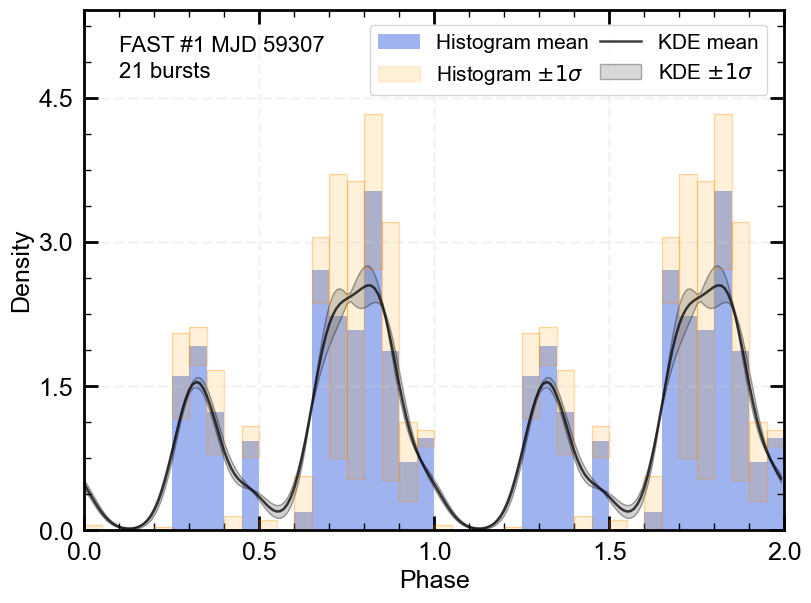

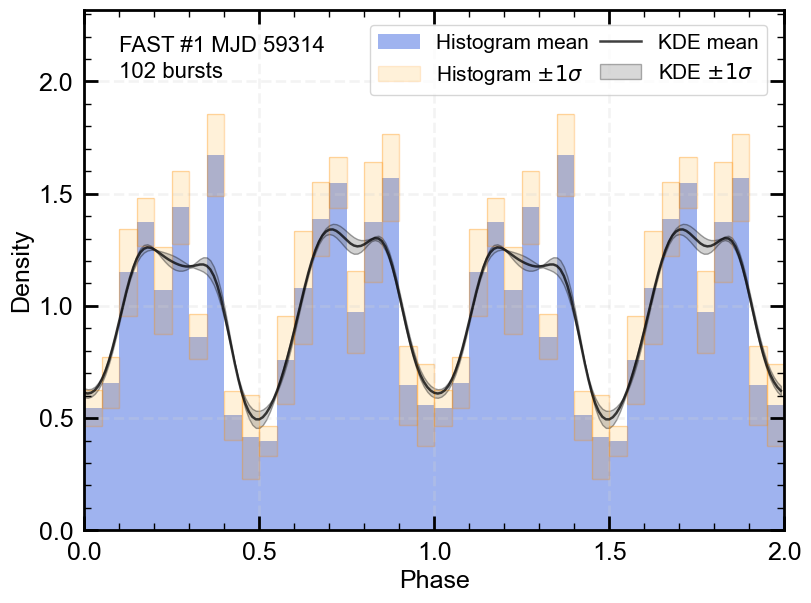

In [31]:
# Phase folding analysis based on a linear period-evolution model
# Plot Figure 6
# For the detailed analysis code, please refer to 'Phase_folding_analysis.py' in the same directory. 
# The results generated by the code are saved in the 'Folded_phases' folder.
import Phase_folding_analysis as pfa

t0_global = np.mean(b_ss_fast1[1][3]['t_s'])   # mean burst TOA on 59310
t1_global = np.mean(b_ss_fast1[1][35]['t_s'])  # mean burst TOA on 59347

P0_mean = 1.706024
P0_err_minus = 0.000013
P0_err_plus = 0.000013

P1_mean = 1.707968
P1_err_minus = 0.000009
P1_err_plus = 0.000009
    
for i in tqdm.tqdm([0,7]): 
    # Figure 6 presents the phase distributions of seven days. 
    # Here, we show the phase distributions for the first two days as example.
    # The phase distributions for each day can be found in the 'Folded_phases' folder.
    b_sss = b_ss_fast1[1][i]

    result = pfa.analyze_one_day_uniformity(
        day_dict=b_sss,
        ds="FAST #1",
        t0_global=t0_global,
        t1_global=t1_global,
        P0_mean=P0_mean,
        P0_err_minus=P0_err_minus,
        P0_err_plus=P0_err_plus,
        P1_mean=P1_mean,
        P1_err_minus=P1_err_minus,
        P1_err_plus=P1_err_plus,
    
        n_mc=10000,
        ref_mode="burst_mean",
        t_ref_user=None,
        random_seed=2026,

        figsize=(8, 6),
        bins=np.linspace(0.0, 1.0, 21),

        draw_kde=True,
        kde_grid=np.linspace(0.0, 1.0, 100, endpoint=False),
        kappa_kde=10.0,

        do_uniformity_tests=False,
        tests=("h"),
        n_null=100000,
        mmax_h=20,
        nbins=8,

        save_dir=None,
        file_tag="",
        rc_dict=None
    )
    



P_hat0 = 1.70602821
P = 1.706023900 +0.000012683 -0.000012502


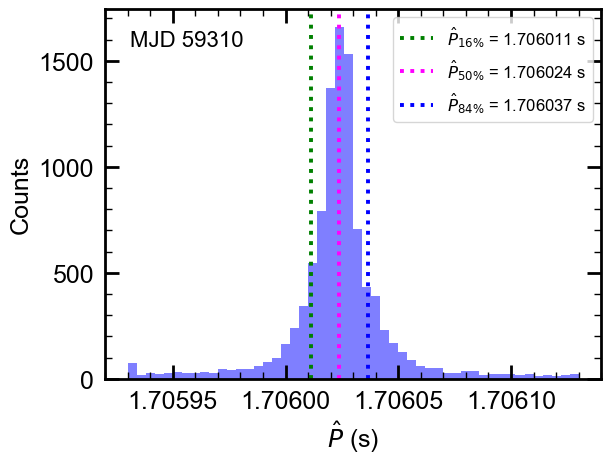

P_hat0 = 1.70797064
P = 1.707967815 +0.000008827 -0.000009245


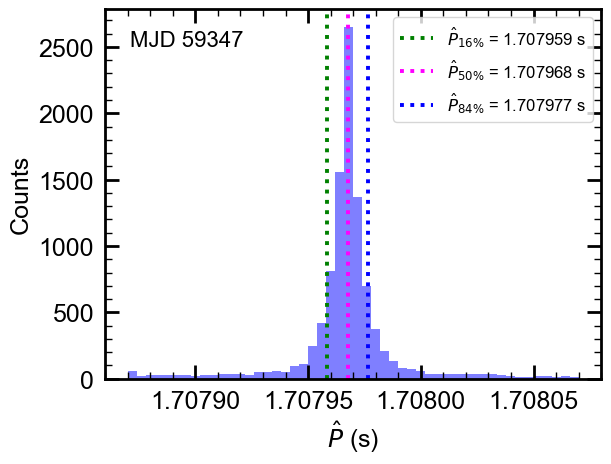

In [14]:
# Period refinement and uncertainty estimation
# Plot Figure 7

# ============================================================
# 1) local_period_search_chi2
# ============================================================
def local_period_search_chi2(t_s, p_center, half_width, step, bins_num, refine=True):

    p_lo = p_center - half_width
    p_hi = p_center + half_width

    n = int(np.round((p_hi - p_lo) / step)) + 1
    n = max(n, 3)
    periods = np.linspace(p_lo, p_hi, n, dtype=np.float64, endpoint=True)

    chi2 = phase_fold_and_calc_chi2_opt(np.asarray(t_s, dtype=np.float64), periods, bins_num)
    imax = int(np.argmax(chi2))
    p_hat = float(periods[imax])

    refine = bool(refine)
    if refine and 0 < imax < len(periods) - 1:
        x1, x2, x3 = periods[imax-1], periods[imax], periods[imax+1]
        y1, y2, y3 = float(chi2[imax-1]), float(chi2[imax]), float(chi2[imax+1])
        denom = (x1 - x2) * (x1 - x3) * (x2 - x3)
        if denom != 0:
            a = (x3 * (y2 - y1) + x2 * (y1 - y3) + x1 * (y3 - y2)) / denom
            b = (x3**2 * (y1 - y2) + x2**2 * (y3 - y1) + x1**2 * (y2 - y3)) / denom
            if a != 0:
                x_peak = -b / (2.0 * a)
                x_peak = min(max(x_peak, x1), x3)
                p_hat = float(x_peak)

    return periods, chi2, p_hat


# ============================================================
# 2) cycle index + phase
# ============================================================
def compute_cycle_and_phase(t, P):
    """
    x = t/P
    n = floor(x)
    phi = x - n in [0,1)
    """
    x = t / P
    n = np.floor(x).astype(np.int64)
    phi = (x - n) % 1.0
    return n, phi


# ============================================================
# 3) Bin + Dirichlet 
# ============================================================
def dirichlet_posterior_from_phases(phases, B=20, alpha0=0.5):
    phases = np.asarray(phases, dtype=np.float64)
    edges = np.linspace(0.0, 1.0, B + 1)
    counts, _ = np.histogram(phases, bins=edges)
    alpha_post = alpha0 + counts.astype(np.float64)
    return counts, alpha_post, edges


def sample_phases_dirichlet(alpha_post, B, size, rng, uniform_mix=0.0):
    """
    posterior predictive:
      p ~ Dirichlet(alpha_post)
      phi ~ mixture( Uniform , Discrete(p) + within-bin uniform jitter )
    """
    uniform_mix = float(uniform_mix)
    if uniform_mix < 0 or uniform_mix > 1:
        raise ValueError("uniform_mix must be in [0,1]")

    phases = np.empty(size, dtype=np.float64)

    if uniform_mix > 0:
        u = rng.random(size)
        mask_u = (u < uniform_mix)
        n_u = int(np.sum(mask_u))
        if n_u > 0:
            phases[mask_u] = rng.random(n_u)
        n_m = size - n_u
        if n_m > 0:
            p = rng.dirichlet(alpha_post)
            bins = rng.choice(B, size=n_m, replace=True, p=p)
            phases[~mask_u] = (bins + rng.random(n_m)) / B
        return phases

    p = rng.dirichlet(alpha_post)
    bins = rng.choice(B, size=size, replace=True, p=p)
    phases[:] = (bins + rng.random(size)) / B
    return phases


# ============================================================
# 4) raw-level generation of TOA: fix brightness labels (no shuffling)
# ============================================================
def simulate_raw_toas_with_fixed_brightness_labels(
    Phat0, 
    n_i, s_labels,
    alpha_post, B,
    rng,
    uniform_mix=0.0,
    jitter_sigma=None,
):
    """
    Given fixed cycle indices n_i (from the observed raw burst) and fixed brightness labels s_labels (same length and same order),
    sample a phase phi* and generate:
    t_unsorted = (n_i + phi*) Phat0
    Then sort by t, and apply the same reordering to s to ensure brightness remains bound to burst identity without mismatching.
    Return:
    t_sorted, s_sorted
    """
    n_i = np.asarray(n_i, dtype=np.int64)
    s_labels = np.asarray(s_labels, dtype=np.float64)
    N = n_i.size

    phi = sample_phases_dirichlet(alpha_post=alpha_post, B=B, size=N, rng=rng, uniform_mix=uniform_mix)
    t_unsorted = (n_i.astype(np.float64) + phi) * float(Phat0)

    if jitter_sigma is not None and jitter_sigma > 0:
        t_unsorted = t_unsorted + rng.normal(0.0, float(jitter_sigma), size=N)

    idx = np.argsort(t_unsorted)
    t_sorted = t_unsorted[idx]
    s_sorted = s_labels[idx]  

    return t_sorted, s_sorted


# ============================================================
# 5) brightest + threshold cluster
# ============================================================
def cluster_brightest_times_from_arrays(t_s, s, threshold):
    """
    Input t_s (in ascending order) and s (aligned). 
    Group them into the same cluster when dt < threshold, and for each cluster, 
    take the t corresponding to the maximum s as the representative.
    """
    t_s = np.asarray(t_s, dtype=np.float64)
    s = np.asarray(s, dtype=np.float64)
    N = t_s.size
    if N == 0:
        return np.empty(0, dtype=np.float64)
    if N == 1:
        return t_s.copy()
    reps = []
    best_idx = 0
    best_s = s[0]
    for i in range(1, N + 1):
        end_cluster = False
        if i == N:
            end_cluster = True
        else:
            if (t_s[i] - t_s[i - 1]) >= threshold:
                end_cluster = True

        if not end_cluster:
            if s[i] > best_s:
                best_s = s[i]
                best_idx = i
        else:
            reps.append(t_s[best_idx])
            if i < N:
                best_idx = i
                best_s = s[i]

    return np.array(reps, dtype=np.float64)


# ============================================================
# 6) main
# ============================================================
def dirichlet_parametric_bootstrap_period_error_fixed_s(
    df_day,
    threshold,
    p_center, half_width, step, bins_num,
    B=20, alpha0=0.5,
    n_boot=2000, seed=1234,
    refine=True,
    uniform_mix=0.0,
    jitter_sigma=None,
    max_resimulate=10,       
):
    rng = np.random.default_rng(seed)

    t_raw = np.asarray(df_day["t_s"], dtype=np.float64)
    s_raw = np.asarray(df_day["s"], dtype=np.float64)

    order0 = np.argsort(t_raw)
    t_raw = t_raw[order0]
    s_raw = s_raw[order0]

    N_raw = int(t_raw.size)

    t_rep_obs = cluster_brightest_times_from_arrays(t_raw, s_raw, threshold=threshold)
    _, _, Phat0 = local_period_search_chi2(
        t_rep_obs, p_center=p_center, half_width=half_width,
        step=step, bins_num=bins_num, refine=refine
    )


    n_i, phi_i = compute_cycle_and_phase(t_raw, Phat0)
    counts, alpha_post, edges = dirichlet_posterior_from_phases(phi_i, B=B, alpha0=alpha0)

    s_labels = s_raw.copy()

    Phats = np.empty(n_boot, dtype=np.float64)

    for k in range(n_boot):
        Phat_k = np.nan
        for _try in range(max_resimulate):
            t_sim_raw, s_sim_raw = simulate_raw_toas_with_fixed_brightness_labels(
                Phat0, 
                n_i=n_i, s_labels=s_labels,
                alpha_post=alpha_post, B=B,
                rng=rng,
                uniform_mix=uniform_mix,
                jitter_sigma=jitter_sigma,
            )
            t_sim_rep = cluster_brightest_times_from_arrays(t_sim_raw, s_sim_raw, threshold=threshold)
            if t_sim_rep.size < 3:
                continue
            _, _, Phat_k = local_period_search_chi2(
                t_sim_rep, p_center=p_center, half_width=half_width,
                step=step, bins_num=bins_num, refine=refine
            )
            break

        Phats[k] = Phat_k

    good = np.isfinite(Phats)
    if np.sum(good) < max(10, int(0.5 * n_boot)):
        raise RuntimeError(f"Too few valid bootstraps: {np.sum(good)}/{n_boot}. Try decreasing uniform_mix/jitter_sigma or increasing max_resimulate.")

    Phats_good = Phats[good]
    P16, P50, P84 = np.percentile(Phats_good, [16, 50, 84])

    return {
        "Phat0": float(Phat0),
        "Phat_samples": Phats_good,
        "N_fail": int(np.sum(~good)),
        "P16": float(P16),
        "P50": float(P50),
        "P84": float(P84),
        "sigma_minus": float(P50 - P16),
        "sigma_plus": float(P84 - P50),
        "N_raw": int(N_raw),
        "N_rep_obs": int(t_rep_obs.size),
        "threshold": float(threshold),
        "B": int(B),
        "alpha0": float(alpha0),
        "uniform_mix": float(uniform_mix),
        "phase_counts": counts,
        "jitter_sigma": None if jitter_sigma is None else float(jitter_sigma),
        "max_resimulate": int(max_resimulate),
        "note": "fixed brightness labels (no shuffle); s is reordered only to match sorted simulated TOAs",
    }
# ============================================================
# 7) MJD 59310 & 59347 PERIOD REFINEMENT
# ============================================================
#MJD 59310
day = 3
b_ss=burstverify_anyday(b_fast1, nummin=1,dnum=1,sep=0)
df_day = b_ss[1][day]

threshold = 0.5
bins_num = 20

P_candidate = 1.70603
half_width = 1e-4
step = 1e-8

res = dirichlet_parametric_bootstrap_period_error_fixed_s(
    df_day=df_day,
    threshold=threshold,
    p_center=P_candidate,
    half_width=half_width,
    step=step,
    bins_num=bins_num,
    B=20,
    alpha0=0.5,
    n_boot=10000,
    seed=2026,
    refine=0,
    uniform_mix=0.0,
    jitter_sigma=1e-4,
)

print("P_hat0 =", res["Phat0"])
print("P = {:.9f} +{:.9f} -{:.9f}".format(
    res["P50"], res["sigma_plus"], res["sigma_minus"]
))

fig, ax = plt.subplots()
plt.hist(res["Phat_samples"], bins=np.linspace(P_candidate-half_width, P_candidate+half_width, 51),
          color="b", alpha=0.5)
plt.axvline(res["P16"], color='green', linestyle=':', label=r'$\hat{P}_{16\%%}$ = %.6f s' % res["P16"])
plt.axvline(res["P50"], color='magenta', linestyle=':', label=r'$\hat{P}_{50\%%}$ = %.6f s' % res["P50"])
plt.axvline(res["P84"], color='blue', linestyle=':', label=r'$\hat{P}_{84\%%}$ = %.6f s' % res["P84"])
plt.xlabel(r"$\hat{P}$ (s)")
ax.yaxis.set_major_locator(MultipleLocator(500))
ax.xaxis.set_major_locator(MultipleLocator(0.00005))
ax.text(0.05, 0.9, 'MJD 59310', transform=ax.transAxes, fontsize=16)
# plt.xlim(P_peak-half_width, P_peak+half_width)
plt.ylabel("Counts")
plt.legend(fontsize=12)
plt.grid()
plt.show()

#MJD 59347
day = 35
b_ss=burstverify_anyday(b_fast1, nummin=1,dnum=1,sep=0)
df_day = b_ss[1][day]

threshold = 0.5
bins_num = 20

P_candidate = 1.70797
half_width = 1e-4
step = 1e-8

res = dirichlet_parametric_bootstrap_period_error_fixed_s(
    df_day=df_day,
    threshold=threshold,
    p_center=P_candidate,
    half_width=half_width,
    step=step,
    bins_num=bins_num,
    B=20,
    alpha0=0.5,
    n_boot=10000,
    seed=2026,
    refine=0,
    uniform_mix=0.0,
    jitter_sigma=1e-4,
)


print("P_hat0 =", res["Phat0"])
print("P = {:.9f} +{:.9f} -{:.9f}".format(
    res["P50"], res["sigma_plus"], res["sigma_minus"]
))

fig, ax = plt.subplots()
plt.hist(res["Phat_samples"], bins=np.linspace(P_candidate-half_width, P_candidate+half_width, 51),
          color="b", alpha=0.5)
plt.axvline(res["P16"], color='green', linestyle=':', label=r'$\hat{P}_{16\%%}$ = %.6f s' % res["P16"])
plt.axvline(res["P50"], color='magenta', linestyle=':', label=r'$\hat{P}_{50\%%}$ = %.6f s' % res["P50"])
plt.axvline(res["P84"], color='blue', linestyle=':', label=r'$\hat{P}_{84\%%}$ = %.6f s' % res["P84"])
plt.xlabel(r"$\hat{P}$ (s)")
ax.yaxis.set_major_locator(MultipleLocator(500))
ax.xaxis.set_major_locator(MultipleLocator(0.00005))
ax.text(0.05, 0.9, 'MJD 59347', transform=ax.transAxes, fontsize=16)
# plt.xlim(P_peak-half_width, P_peak+half_width)
plt.ylabel("Counts")
plt.legend(fontsize=12)
plt.grid()
plt.show()


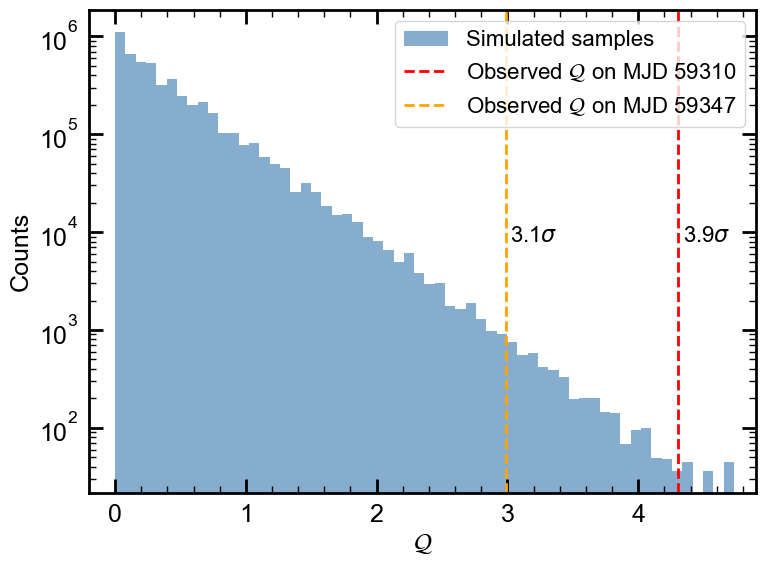

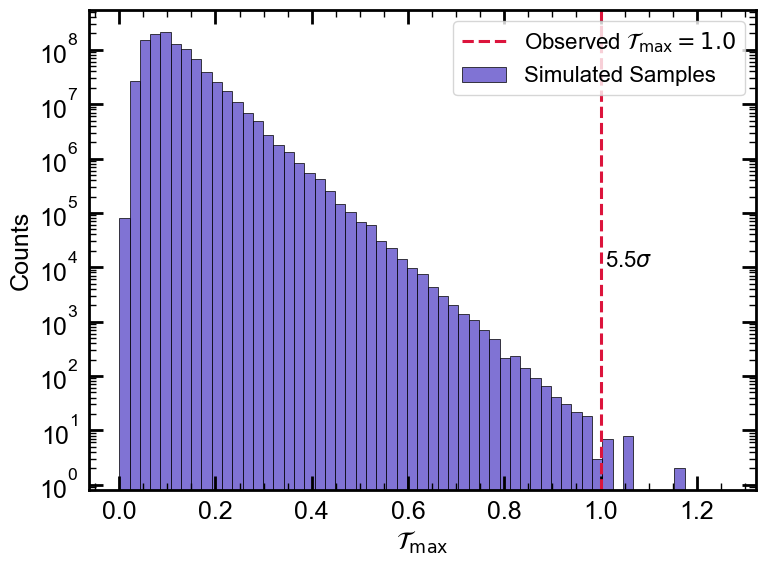

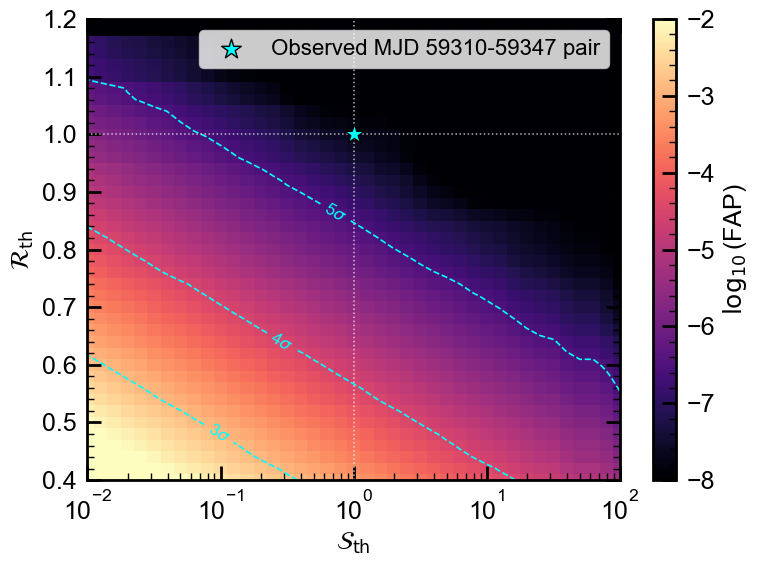

In [22]:
# Period significance analysis
# Plot Figures 8, 9, 10
# For the detailed significance analysis code, please refer to 'Significance_analysis.py' in the same directory. 
# The generated results are saved in 'Significance_results' folder, and here we only import those results for plotting.
import importlib
import Significance_analysis as sa
sa = importlib.reload(sa)


libs = sa.load_all_unit_libraries(r"Significance_results/UnitLibraries_allunits", baseseedx=2026, nlocal=100000)
libs = sa.calibrate_all_libraries(libs)
fig_q = sa.plot_q_null_distribution(libs, figsize=(8, 6))

hist_data=sa.load_global_t_null_binned_histogram_data('Significance_results/GlobalSingle_allunits/GLOBALSINGLE_ALLUNITS_N1000000000_seed2026_histbins.npz')
fig_t = sa.plot_global_t_null_distribution_from_binned_data(hist_data, logy=1)

meta_grid, arr_grid,_ = sa.load_global_RSgrid2d_result('Significance_results/GlobalGrid2D_allunits/GLOBALRSGRID2D_ALLUNITS_N1000000000_seed2026_NR41_NS41.npz')

fig_grid = sa.plot_global_RS_grid_heatmap(meta_grid, arr_grid, log10_color=True, mark_target=True)

